In [1]:
import numpy as np
import seaborn as sns
from matplotlib import gridspec
import matplotlib.pyplot as plt
from esg.models import SmithWilson

In [2]:
# 환경설정
plt.style.use('default')
plt.rc('figure', figsize=(10, 5))
plt.rc('axes', unicode_minus=False)
plt.rc('font', family='Malgun Gothic')
plt.style.use('seaborn')

In [3]:
# 데이터 입력
data = np.array([
    [1, 0.01339],
    [2, 0.01365],
    [3, 0.01355],
    [5, 0.01470],
    [7, 0.01608],
    [10, 0.01672],
    [20, 0.01702]
])
X_train = data[:, 0]
y_train = data[:, 1]
ltfr, terminal = 0.052, 60

# SW 모델 생성 및 α 학습
sw = SmithWilson(np.log(1+ltfr), terminal)
sw.train(X_train, y_train)

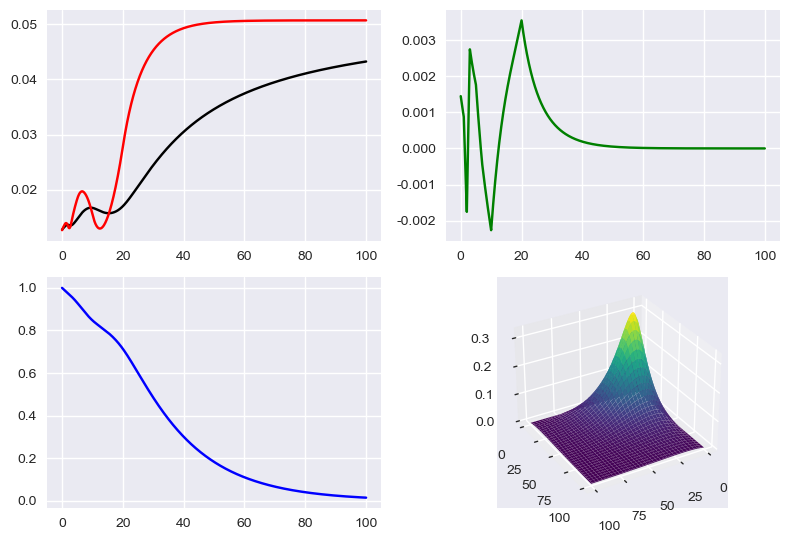

In [4]:
fig = plt.figure()
gs = gridspec.GridSpec(2, 2)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1], projection='3d')


t = np.arange(0, 100+1e-6, 1/12)
t2 = np.arange(1e-6, 100+2e-6, 1/12)
r = sw.spot(t)
f = sw.forward(t)
f2 = sw.forward(t, order=1)
# f22 = (sw.forward(t2)-sw.forward(t))/1e-6
p = sw.bond(t)
ax00.plot(t, r, c='black')
ax00.plot(t, f, c='red')
ax01.plot(t, f2, c='green')
# ax01.plot(t, f22, c='green')
ax10.plot(t, p, c='blue')

x = np.arange(0, 101)
X = np.tile(x, (101, 1))
Y = np.transpose(X)
Z = sw._wilson(X, Y, sw._alpha)
ax11.plot_surface(X, Y, Z, cmap='viridis')
ax11.view_init(30, 60)

fig.tight_layout()
plt.show()

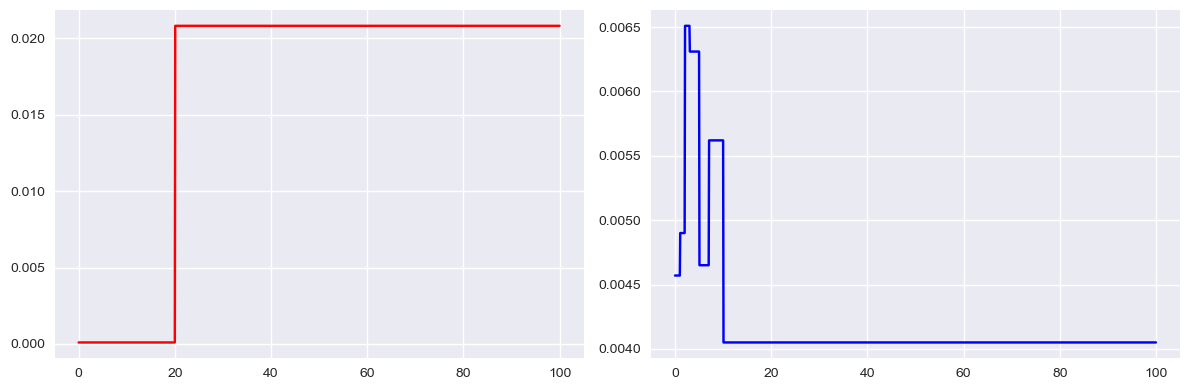

In [5]:
def alpha(t: float) -> float:
    if t<0: raise Exception("t 입력 오류")
    elif t<=20: value = 0.0001 
    else: value = 0.02082
    return value

def sigma(t: float) -> float:
    if t<0: raise Exception("t 입력 오류")
    elif t<=1: value = 0.00457
    elif t<=2: value = 0.00490
    elif t<=3: value = 0.00651
    elif t<=5: value = 0.00631
    elif t<=7: value = 0.00465
    elif t<=10: value = 0.00562
    else: value = 0.00405
    return value

fig = plt.figure(figsize=(12, 4))

ax0 = fig.add_subplot(121)
ax1 = fig.add_subplot(122)
t = np.arange(0, 100+1e-6, 1/12)
alp = np.array([alpha(s) for s in t])
sig = np.array([sigma(s) for s in t])
ax0.plot(t, alp, c='red')
ax1.plot(t, sig, c='blue')

fig.tight_layout()
plt.show()

In [43]:
from scipy.integrate import quad

class HullWhite:
    
    def __init__(self, curve: SmithWilson):
        self.curve = curve

    def alpha(self, t: float) -> float:
        if t<0: raise Exception("t 입력 오류")
        elif t<=20: value = 0.0001 
        else: value = 0.02082
        return value

    def sigma(self, t: float) -> float:
        if t<0: raise Exception("t 입력 오류")
        elif t<=1: value = 0.00457
        elif t<=2: value = 0.00490
        elif t<=3: value = 0.00651
        elif t<=5: value = 0.00631
        elif t<=7: value = 0.00465
        elif t<=10: value = 0.00562
        else: value = 0.00405
        return value
        # return 0

    def E(self, t: float) -> float:
        if t<0: raise Exception("t 입력 오류")
        elif t<=20: integral = 0.0001*t 
        else: integral = 0.0001*20+0.02082*(t-20)
        value = np.exp(integral)
        return value

    def B(self, t: float, T: float) -> float:
        if t<0 or T<t:
            raise Exception('(t, T) 입력 오류')
        elif t<=20 and T<=20:
            value = 1/0.0001*(1-np.exp(-0.0001*(T-t)))
        elif t<=20 and T>20:
            value = 1/0.0001*(1-np.exp(-0.0001*(20-t)))+1/0.02082*(np.exp(-0.02082*20)-np.exp(-0.02082*T))*np.exp(0.0001*t)
        elif t>20 and T>20:
            value = 1/0.02082*(1-np.exp(-0.02082*(T-t)))
        return value

    def sigma2(self, u: float, T: float) -> float:
        return self.sigma(u)*self.B(u, T)

    def theta(self, t: float) -> float:
        value = self.curve.forward(t, 1)+self.alpha(t)*self.curve.forward(t)+0.5*(self.deriv_V_0t(t, 2)+self.alpha(t)*self.deriv_V_0t(t, 1))
        return value

    def deriv_V_0t(self, t: float, order: int) -> float:
        if order == 1:
            return 2/self.E(t)*quad(lambda u: self.sigma(u)**2*self.E(u)*self.B(u, t), 0, t, limit=200)[0]
        elif order == 2:
            return quad(lambda u: self.sigma(u)**2*self.E(u)/self.E(t)*(-self.alpha(t)*self.B(u, t)+self.E(u)/self.E(t)), 0, t, limit=200)[0]
        else:
            raise Exception("order 입력 오류")

    def generate_scenario(self, t: float, n: int, dt: float = 1/12):
        m = int(t/dt)
        r = np.zeros([m+1, n])
        r[0] = self.curve.forward(0)
        dW = np.random.normal(0, np.sqrt(dt), size=(m, n))
        t = np.arange(0, t+dt, dt)
        for i in range(m):
            r[i+1] = r[i] + (self.theta(t[i])-self.alpha(t[i])*r[i])*dt + self.sigma(t[i])*dW[i]
        return r

In [44]:
hw = HullWhite(sw)

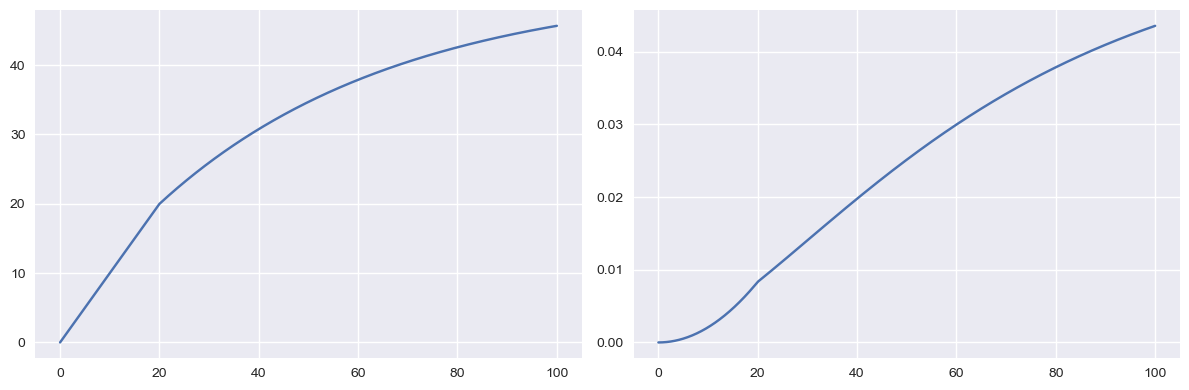

In [45]:
import ipywidgets as widgets
@widgets.interact(t=widgets.FloatSlider(min=0, max=100, value=0))
def plot(t):
    T = np.arange(t, 100+1e-6, 1/12)
    b = np.array([hw.B(t, s) for s in T])
    sig2 = np.array([hw.sigma2(t, s)**2 for s in T])
    
    fig = plt.figure(figsize=(12, 4))
    ax0 = fig.add_subplot(121)
    ax1 = fig.add_subplot(122)
    ax0.plot(T, b)
    ax1.plot(T, sig2)

    fig.tight_layout()
    plt.show()

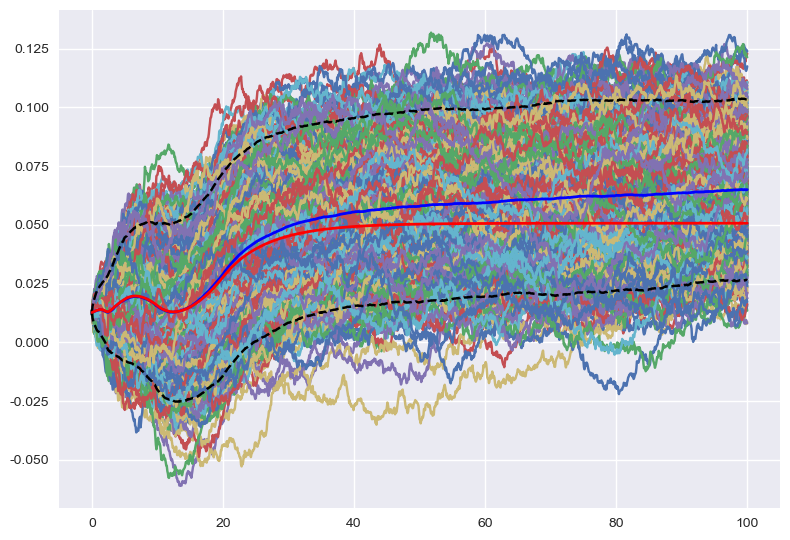

In [49]:
scen = hw.generate_scenario(t=100, n=1000)
scen_mean = scen.mean(axis=1)
vol = scen.std(axis=1)
t = np.arange(0, 100+1e-6, 1/12)
f = hw.curve.forward(t)
plt.plot(t, scen)
plt.plot(t, scen_mean, c='blue', lw=2)
plt.plot(t, scen_mean-1.96*vol, c='black', linestyle='--')
plt.plot(t, scen_mean+1.96*vol, c='black', linestyle='--')
plt.plot(t, f, c='red', lw=2)
plt.tight_layout()
plt.savefig('scenario.png')
plt.show()

In [47]:
np.savetxt('scenario.csv', scen)